# Goal of the project

The goal of this project is to control a 2D quadrotor to perform acrobatic moves. There are 4 parts of the project, where you will build controllers of increasing complexity. The last part will lead to the implementation of the iterative LQR (iLQR) algorithm.

## Instructions
Answer all the questions in the 4 parts below. You will need to submit:
1. A report (pdf format only - every other format will be rejected) answering all the questions that do not request code. DO NOT include code in the report.
2. One (or several) Jupyter notebook(s) containing all the code used to answer the questions. The notebook(s) should be runnable as is.

## 2D quadrotor

The quadrotor is depicted in the following figure <img src='quadrotor.png' width="300">
The quadrotor model is written as
$$\begin{align} 
\dot{x} &= v_x\\
m \dot{v}_x &= - (u_1 + u_2) \sin \theta \\ 
\dot{y} &= v_y\\
m \dot{v}_y &= (u_1 + u_2) \cos \theta  - m g\\
\dot{\theta} &= \omega\\
I \dot{\omega} &= r (u_1 - u_2) \end{align}$$
where $x$ is the horizontal and $y$ the vertical positions of the quadrotor and $\theta$ is its orientation with respect to the horizontal plane. $v_x$ and $v_y$ are the linear velocities and $\omega$ is the angular velocity of the robot. $u_1$ and $u_2$ are the forces produced by the rotors (our control inputs). $m$ is the quadrotor mass, $I$ its moment of inertia (a scalar), $r$ is the distance from the center of the robot frame to the propellers and $g$ is the gravity constant. To denote the entire state, we will write $z = [x, v_x, y, v_y, \theta, \omega]^T$ - we will also write $u = [u_1, u_2]^T$.

The module ```quadrotor.py``` defines useful constants (mass, length, gravity, etc) and functions to simulate and animate the quadrotor as shown below.

## Part 1 - Setting up
1. Discretize the system dynamics using the method seen in class - write the time discretization step as $\Delta t$ (use symbols not numbers for the mass, etc)
2. Assume that the robot starts at an arbitrary position $x(0) = x_0$, $y(0) = y_0$ and $\theta(0) = 0$ with 0 velocities. Compute $u_1^*$ and $u_2^*$ such that the robot stays at this position forever after (you may test your answer using the simulation below).
3. Analyzing the system dynamics, is it possible to move in the x direction while keeping $\theta = 0$? Explain why.
4. Analyzing the system dynamics, is it possible to have the system at rest with $\theta = \frac{\pi}{2}$ (i.e. have the quadrotor in a vertical position)? Explain why.

## Part 2 - LQR to stay in place
Now that we have $u^*$ capable of keeping the robot at rest, we can design a simple controller that ensures that the robot stays in place even when pushed around by random disturbances (e.g. due to the wind). Our task here will be to design a LQR controller that keeps the robot at a predefined position. Since the dynamics is not linear, we need to compute a linear approximation of it.
1. Linearize the dynamics at an arbitrary operating point $z^*$, $u^*$ and write the linearized system dynamics using the variables $\bar{z}_n = z_n - z^*$ and $\bar{u}_n = u_n - u^*$.
2. Write a function ```get_linearization(z, u)``` that returns the matrices A and B given a state $z$ and a control $u$ (use the constants defined in the ``quadrotor.py`` module).
3. Using the linearized dynamics, we can design an infinite horizon LQR controller of the form, $\hat{u} = K \bar{z}$ to stabilize the resting point. Write the equations of the controller in the original coordinates $u$ as a function of $z$.
4. Design an infinite-horizon LQR controller that stabilizes the origin $z=0$ and test it using the simulator below.
5. Explain your intended design in the report, including the cost function and found control law. In particular, verify that it can handle perturbations by calling the ```simulate``` function with ```disturbance = True``` (when setting disturbance to ``True``, the simulator will generate a random perturbation every 1 second). Simulate your controller for 10 seconds, plot the state evolution and show the animation (include the plots in your report).

## Part 3 - following a trajectory using linearized dynamics
Now we want to follow a given trajectory leveraging a linearized version of the dynamics to design LQ controllers.
1. Assume that we want to follow a circle of radius 1 centered at (0,0) while keeping an orientation $\theta=0$, how does the linearization of the dynamics change along the desired trajectory? Why?
2. Design a tracking controller (using an LQ design with linear approximations) to follow this desired trajectory. Explain your design in the report. 
3. Test the tracking controller with the simulation (with and without the perturbations) and verify that you can indeed track the (x,y) trajectory very well. Are you able to also track $\theta$? (Explain) 
4. Analyze your results (including plots of the states, controls, etc). What benefits and issues do you see with this approach?
5. Is it possible to do the same thing while keeping a desired orientation of $\theta = \frac{\pi}{4}$? What might influence the results in this case?

## Part 4 - iterative LQR
Now we would like to do more complicated motions with the robot, like a flip. In this case, we do not have a prescribed trajectory but we would like to compute a locally optimal trajectory while we optimize the controller. We will use the *iterative LQR* algorithm to solve this problem.
### Task 1 - reaching a vertical orientation
In the first task, we want the robot to reach a vertical orientation $\theta = \frac{\pi}{2}$ at the location $x=3$ and $y=3$ at time $t=5$ starting from $z_0=0$. During the rest of the motion, the robot should try and stay close to the origin. It should also try to keep its control $u$ close to the control needed to keep the robot at rest. We want to make sure the robot reaches the origin $z=0$ at the end of the movement. 
1. Find a time-varying cost function that promotes such a behavior (use only quadratic/linear terms for simplicity). Assume $T=10$ seconds.
2. Write a function ```compute_cost(z,u, horizon_length)``` that returns the cost of a trajectory z with control trajectory u (using the cost function you wrote in question 1).
3. Compute the quadratic approximation of your cost function along an arbitrary trajectory of states $z_n$ with control trajectory $u_n$ (this is not just your cost function!)
4. Write a function ```get_quadratic_approximation_cost(z, u, horizon_length)``` that returns the quadratic approximation (Hessian matrices and Jacobians) of the cost function when approximated along the trajectory z with control trajectory u.
5. Write the iLQR algorithm that solves the problem using the functions written above. DO NOT FORGET the line search step at each iteration. For the line search, start with $\alpha = 1.$ and decrease it by half when the cost does not improve (you can stop when $\alpha < 0.01$).
6. Test the algorithm using as initial guess $u$ such that the robot is at rest (using the results of Part 1.2). Analyze your results (probably you will need to "tune" your cost function), plot the initial and final state and control trajectories, show the animation. Use the simulation without perturbations for simplicity. 
7. What benefits and issues do you see with this approach?
### Task 2 - doing a full flip
In the second task, we want the robot to do a full flip, trying to reach the upside-down state $x=1.5$, $y=3$ and $\theta = \pi$ at $t=5$ and upright state $x=3$, $y=0$ and $\theta = 2\pi$ at $T=10$.
8. Use iLQR (and a new cost function) to get the quadrotor to perform the task. Analyze your results. 
9. What benefits and issues do you see with this approach? Could you run the resulting controller on a real robot?

In [1]:
%matplotlib inline 
#%matplotlib notebook  #uncomment for Jupyter
#%matplotlib inline     #uncomment for VSCode

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from numpy import sin, cos, pi
import quadrotor

def save_plt(title, flag=True):
    if flag:
        plt.savefig(f'data_viz/{title}-Task1.png')

def save_animate(title, animate_object, flag=True):
    my_anim, fps = animate_object
    if flag:
        my_anim.save(f'data_viz/{title}-Task1.mp4', writer='ffmpeg', fps=fps, dpi=200)
        my_anim.save(f'data_viz/{title}-Task1.gif', writer='pillow', fps=fps, dpi=200)

In [3]:
# we can get its mass, half length (r), gravity constant
print(f'm is {quadrotor.MASS}')
print(f'r is {quadrotor.LENGTH}')
print(f'I is {quadrotor.INERTIA}')
print(f'g is {quadrotor.GRAVITY}')

# we can also get the integration step used in the simulation
print(f'dt is {quadrotor.DELTA_T}')

# we can get the size of its state and control vector
print(f'number of states {quadrotor.NUMBER_STATES} and number of controls {quadrotor.NUMBER_CONTROLS}')
print('the states are indexed as follows: x, vx, y, vy, theta, omega')

m is 0.6
r is 0.2
I is 0.15
g is 9.81
dt is 0.01
number of states 6 and number of controls 2
the states are indexed as follows: x, vx, y, vy, theta, omega


In [4]:
# we can simulate the robot but we need to provide a controller of the following form
def dummy_controller(state, i):
    """
        the prototype of a controller is as follows
        state is a column vector containing the state of the robot
        i is the index corresponding to the time step in the horizon (useful to index gains K for e.g.)
        
        this controller needs to return an array of size (2,)
    """

    def solve_LQR(A, B, Q, R, QN, N):
        P_n=[]
        K_n=[]
        list_of_P = []
        list_of_K = []
        K=N+1
        for i in range(0,K):
            if i == 0:
                PN=QN
                P=PN
                list_of_P=[P]

            else:
                Y=np.matmul(np.transpose(B),P)
                Y1=np.linalg.inv(np.matmul(Y,B)+R)
                K_n=np.matmul(np.matmul(-Y1,Y),A)

                Z=np.matmul(np.transpose(A),P)
                Z1=np.matmul(np.matmul(Z,B),K_n)
                P_n=Q+np.matmul(Z,A)+(Z1)
                P=P_n

                list_of_P.insert(0,P)
                list_of_K.insert(0,K_n)

        return list_of_P, list_of_K

    dt=quadrotor.DELTA_T
    mass=quadrotor.MASS
    Len=quadrotor.LENGTH
    Inertia=quadrotor.INERTIA
    grav=quadrotor.GRAVITY
    r_size=state.shape[0]

    #_____________________
    x00=1
    y00=1
    theta00=np.deg2rad(0)
    state[0]=x00
    state[2]=y00
    state[5]=theta00
    theta=state[5]
    #____________________


    #________________________
    A=np.eye(r_size)
    A[0,1]=dt
    A[2,3]=dt
    A[4,5]=dt
    #________________________
    B=np.zeros((r_size,2))
    B[1,0]=-sin(theta)*dt/mass
    B[3,0]=cos(theta)*dt/mass
    B[5,0]=Len*dt/Inertia
    B[1,1]=-sin(theta)*dt/mass
    B[3,1]=cos(theta)*dt/mass
    B[5,1]=-Len*dt/Inertia
    #________________________
    C=np.zeros((r_size,))
    C[3]=grav
    #______________________
    Q=np.eye(r_size)*100
    R=np.eye(2)*0.01
    QN=Q
    N=1*10*3
    
    P,K=solve_LQR(A,B,Q,R,QN,N)

    x0=state
    x=x0.reshape(len(x0),1) 
    for i in range(N):
        K_n=K[i][:][:]   #Initializing necessary variable to store K_n
        x_n = x[:,i]     #Initializing necessary variable to store x_n

        u_n=np.matmul(K_n,x_n) #Formula from Prof L. Righetti
        if i == 0: #Conditional to resolve an error, because stacking doesn't work with empty variables
            u=u_n.reshape(len(u_n),1) #rehape of u/u_n to allow for stacking
        else:
            u=np.hstack((u,u_n.reshape(len(u_n),1))) #rehape of v_n to allow for stacking

        x_n1=(A@x_n)+(B@u_n)+C #Formula from Prof L. Righetti
        #C causes the read lines, experiment later.
        x=np.hstack((x,x_n1.reshape(len(x0),1)))    #rehape of x_n to allow for stacking
    u_optimal=u

    u_star=K*state
    print(u_star[N-1,:,5])
    # here we do nothing and just return some non-zero control
    return u_star[N-1,:,5]#u_optimal[:,N-1]




# we can now simulate for a given number of time steps - here we do 10 seconds
horizon_length = 1000
z0 = np.zeros([quadrotor.NUMBER_STATES,])
t, state, u = quadrotor.simulate(z0, dummy_controller, horizon_length, disturbance = False)

[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]


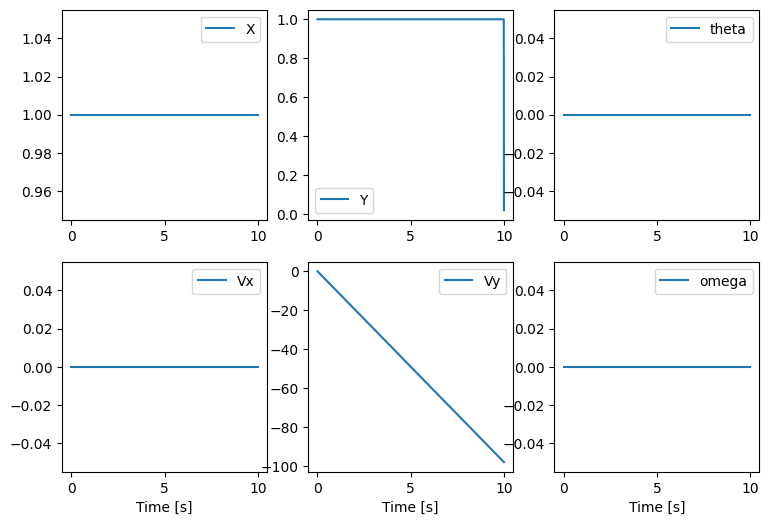

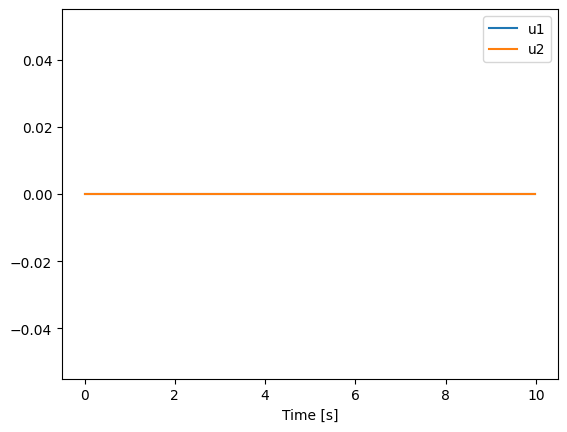

In [5]:
# we can plot the results
plt.figure(figsize=[9,6])

plt.subplot(2,3,1)
plt.plot(t, state[0,:])
plt.legend(['X'])

plt.subplot(2,3,2)
plt.plot(t, state[2,:])
plt.legend(['Y'])

plt.subplot(2,3,3)
plt.plot(t, state[4,:])
plt.legend(["theta"])

plt.subplot(2,3,4)
plt.plot(t, state[1,:])
plt.legend(['Vx'])
plt.xlabel('Time [s]')

plt.subplot(2,3,5)
plt.plot(t, state[3,:])
plt.legend(['Vy'])
plt.xlabel('Time [s]')

plt.subplot(2,3,6)
plt.plot(t, state[5,:])
plt.legend(['omega'])
plt.xlabel('Time [s]')

save_plt(title="2D translation, orientaion and speed vs time a")

# we can also plot the control
plt.figure()
plt.plot(t[:-1], u.T)
plt.legend(['u1', 'u2'])
plt.xlabel('Time [s]')
save_plt(title="Control vs time a")

In [6]:
# now we can also create an animation
#quadrotor.animate_robot(state, u)
save_animate('my_animation a', quadrotor.animate_robot(state, u, pass_fps=True))

<source type="video/mp4" src="data:video/mp4;base64,AAAAIGZ0eXBNNFYgAAACAE00ViBpc29taXNvMmF2YzEAAAAIZnJlZQAAI7ptZGF0AAACrgYF//+q
3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzEwOCAzMWUxOWY5IC0gSC4yNjQvTVBF
Ry00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyMyAtIGh0dHA6Ly93d3cudmlkZW9sYW4u
b3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFs
eXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVk
X3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBk
ZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTMg
bG9va2FoZWFkX3RocmVhZHM9MSBzbGljZWRfdGhyZWFkcz0wIG5yPTAgZGVjaW1hdGU9MSBpbnRl
cmxhY2VkPTAgYmx1cmF5X2NvbXBhdD0wIGNvbnN0cmFpbmVkX2ludHJhPTAgYmZyYW1lcz0zIGJf
cHlyYW1pZD0yIGJfYWRhcHQ9MSBiX2JpYXM9MCBkaXJlY3Q9MSB3ZWlnaHRiPTEgb3Blbl9nb3A9
MCB3ZWlnaHRwPTIga2V5aW50PTI1MCBrZXlpbnRfbWluPTEwIHNjZW5lY3V0PTQwIGludHJhX3Jl
ZnJlc2g9MCByY19sb29rYWhlYWQ9NDAgcmM9Y3JmIG1idHJlZT0xIGNyZj0yMy4wIHFjb21wPTAu
NjAgcXBtaW49MCBxcG1heD02OSBxcHN0ZXA9NCBpcF9yYXRpbz0xLjQwIGFxPTE6MS4wMACAAAAS
hGWIhAAR//73iB8yy2n5OtdyEeetLq0fUO5GcV6kvf4gAAADAAADAAADAAqSWJ4ih/F4zfwAAAMA
ALeAF7AMIAqoDCo+iHZ3Z08wCIkevjpw21ZE46T3sRhy46F2N9IZFxIUhPZBCiCTW6wKQiOBu94o
R2YuE9StYqIOVnNKeqSx04QsApp2IUqmKWG06Np+bWY5fUnq7HN65sUwlNWhuXo1pX9mYgT7Ser7
mRH+hQlj3pK4394jsYPZ2HgAt//3pGielLqfKRJ1++ALReZojwl5hmKdVYCJTIW5ShNX+Vy5cW9R
1F5rhvnxIAwgCTYIK0ljKBVUvDhaWgwzL0juuKZs4erxw6CrX5nAOItdrlLIe68DWXvwSOy3W2mg
phZWihuqd1pWWQToC3Ol4eihqgZPg10yL85pxnWhP72FWa6UKhObVpR9cC86bAlV4WjIcMipSB2F
wsyOe4TdRl5OQCbO/JC9y9LhXhPAjonQzhXeMs5KHv+5doesBCjs+7hYAAXQAAAYE/1y9HkfJOid
5USBnE5YYfy4EHprwfS3jjj20v4qPWxCqZLTM1LK9qx+5+4J/gFuWsl+/jj107CVouQH+nJfkJ89
Llvg2AS0uadrYV6aLwg5OerXMFtKYAJp+X39oV15iPS0BN6Vhs/Wr2Y50YxuFTcb0Q+jCQbqBhWc
9E2YeB3o11/l6+gGNTbS4RuQ7dBRU+4Xg8tk/yeerLQoi6JWGhAuC7H9wWv5tas1nzBCMgDae2gz
yqDB70/WYwCr+xQWV18X9Hd4PHU5+KU39RkDxkZn8rVEMkBpmiQLQoS9eZtwX29k7Vtft4M0mdUt
UYOAR+WTxNuM9/axfRKDwC6Lso6v7ZLJgNMZ75TqtjUEO50Bsvvh51mjL+vI3mS3yLKZx5BmC5Wo
hx/Pu/4MV5KaaKm21cxpGziwJVMbgdx5HKeaM8ERSRJH32KJAAADAAADAAADAAAFOitllAK02sXi
fhQCOngzpQuNUKyt3x2jzgOk5Ie/w8MbGGnm4ulIJ1vjqnaxCY1cbyOLKQo2zlUgccI4DniJcIca
uaKHoL4aQ3eUxrR2twlwUjdaywXJ2epWD5WXUsnVAhBQA6jAWropzzy+/3Pu97VBvhQGDq2isqTW
umY21n9P9d7r4TP4SNkcb3QLJoQ9ntxVldBmI26m0b3dMSa8826KwuA1lJYLVhWhNV3t450oZHgT
Zu1YXqq/eoQ3FIijSJkU3hsJXiyDT1nWen4lMsYYyN36JIBqiCSA2rcOqD/4FX7Brknzx+tUpMWo
x/1I6Z/nteagpVcAfJ4uNBiLA04C7ZANsHPLowEBFR/lXZ4VehoU4xcE/62N8+wdyZ1VewED+oKA
ZRLIEgAA3bu5Zg/74qhAIkTISSAB8kskQgA35TB25LR+0ZVr8P85701piL9d0b4zvqq5k5/yBBgj
IiPQRhQcouQtuG9OT0hQcT5NIIKIZiMXGYb5pYCg0WPJpQqh8aDeD1GO2TymzpOb8uwdVLuyHBiX
NdwtZywzJpuZapes2MI34Hil8Wv3MadG8RBqMxkINwdqd6WKIqDipiL5sajFtusubDyo6YwiY2wZ
c2zZBbJN6IMwCuChdMfDJvd1NLOEP0ozXYw03vnZs829gCxb1e23z9dngKv4+nJbogTUHDv4z1gA
BhP1/FrYHRAsyIRRJnZQHPe5lQLlhk7ZJ/JOw1ZXPq01aEWh+IsKnW4W8knbG6EmxG/8TG2Eh271
FsxDrcbowEA2qkM87VPj3z1YVcq7dS+I59KEHgjeO9Iydfv/rQHydPeCF4j0CXrISi53DOPkzZVz
zriAVfcq4771dBAIW2O3+7fik+efl1fxCBrXsrjvx9jDosd0h6xjAlr32HETS4bI0ldW5JJpqV0L
7P+Jvf5wIyaWQnIEX8zBJw1Ehml0PqOXurX+2+40Q1mXt07Fuc8RwQX6mej+fsPUmbzD0PInqnZl
6lcbFHHoC8uAZPi26IVS9KoBRdPsdMU7QW38kMctzH++iuM/y//0Uy8hhOBUVCsJQRtk4LdJPUIH
wt7/rG485QUtaOenY5T+FYrTJ1iYfJhQemnxWV2W66xMv716WzymHc7rUtlghSXqtns2SJF0UvUD
CTWP4+bizyEKehEqyT6Y4diIMZIcK62/3rSARLPxD5lYfSTnSuarOB/GsH4y2IBUj5N0Bg7tzlHE
aa9KVaiBE5OSsD8JwNSS+RDOiVQu9Fvw/X9bvnb9498GaXtsCKDNt6+cb3z23unq2QhAohKo0yJH
Q01cmlijV12JPqMDsPMr2V84hBs/sxLiBNl3PhrQxuo/B6pWmoBycV/jNKPMcW87tQLZYkl0L/dv
sKwDA24iyW2VVPRUiCw8HxuYkfKJ6fiS5goD7RPLWblY666B1NuoFeFFSYGobv28hhquNjUtSEsc
tGXctC1+mHEqgnG3fxv2crX2DS3bDnnnDecTuOUlLUAuuh+7DDJVNdKOFdT7jAxKmqP/Dg6vXEpz
iNoXamlp6zpRBT3bw7lVdAfMKG0QAUGvs6CmUFvfgMFNNLuP5U9o6ovhFWewXQLBac8kNnydJgIt
OpYEk4q3IxHx7f7+ooScikU7Og1jfMtuo3NM2xEvtFN/Fhla8oSrh88XnTmhT538CwI9P+GFTxc1
hfOCVQI4JmYACVnGkckYmVQb+f591OfMEeVemioGXJ1Of82HHyrMPxroPje6/womBibtM3MmVEJK
zXaxpRhRFtndlPNR1PKFE4prKx4L4dvs8i+Gg7i2Z8KxhkPElTrlyJrCaSrSME5cNKtV52uz3yfO
R7W3NYLWxPS1Vi6HxKHVrSN4i4pJk0jO9e9ePQfgJMfv5LTurrU6TA42thsatq8uXA6bOjBJaFHQ
0iFQdj5hBZ9htbXWWX0UE

[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]
[-0.  0.]


<source type="video/mp4" src="data:video/mp4;base64,AAAAIGZ0eXBNNFYgAAACAE00ViBpc29taXNvMmF2YzEAAAAIZnJlZQAAI7ptZGF0AAACrgYF//+q
3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzEwOCAzMWUxOWY5IC0gSC4yNjQvTVBF
Ry00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyMyAtIGh0dHA6Ly93d3cudmlkZW9sYW4u
b3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFs
eXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVk
X3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBk
ZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTMg
bG9va2FoZWFkX3RocmVhZHM9MSBzbGljZWRfdGhyZWFkcz0wIG5yPTAgZGVjaW1hdGU9MSBpbnRl
cmxhY2VkPTAgYmx1cmF5X2NvbXBhdD0wIGNvbnN0cmFpbmVkX2ludHJhPTAgYmZyYW1lcz0zIGJf
cHlyYW1pZD0yIGJfYWRhcHQ9MSBiX2JpYXM9MCBkaXJlY3Q9MSB3ZWlnaHRiPTEgb3Blbl9nb3A9
MCB3ZWlnaHRwPTIga2V5aW50PTI1MCBrZXlpbnRfbWluPTEwIHNjZW5lY3V0PTQwIGludHJhX3Jl
ZnJlc2g9MCByY19sb29rYWhlYWQ9NDAgcmM9Y3JmIG1idHJlZT0xIGNyZj0yMy4wIHFjb21wPTAu
NjAgcXBtaW49MCBxcG1heD02OSBxcHN0ZXA9NCBpcF9yYXRpbz0xLjQwIGFxPTE6MS4wMACAAAAS
hGWIhAAR//73iB8yy2n5OtdyEeetLq0fUO5GcV6kvf4gAAADAAADAAADAAqSWJ4ih/F4zfwAAAMA
ALeAF7AMIAqoDCo+iHZ3Z08wCIkevjpw21ZE46T3sRhy46F2N9IZFxIUhPZBCiCTW6wKQiOBu94o
R2YuE9StYqIOVnNKeqSx04QsApp2IUqmKWG06Np+bWY5fUnq7HN65sUwlNWhuXo1pX9mYgT7Ser7
mRH+hQlj3pK4394jsYPZ2HgAt//3pGielLqfKRJ1++ALReZojwl5hmKdVYCJTIW5ShNX+Vy5cW9R
1F5rhvnxIAwgCTYIK0ljKBVUvDhaWgwzL0juuKZs4erxw6CrX5nAOItdrlLIe68DWXvwSOy3W2mg
phZWihuqd1pWWQToC3Ol4eihqgZPg10yL85pxnWhP72FWa6UKhObVpR9cC86bAlV4WjIcMipSB2F
wsyOe4TdRl5OQCbO/JC9y9LhXhPAjonQzhXeMs5KHv+5doesBCjs+7hYAAXQAAAYE/1y9HkfJOid
5USBnE5YYfy4EHprwfS3jjj20v4qPWxCqZLTM1LK9qx+5+4J/gFuWsl+/jj107CVouQH+nJfkJ89
Llvg2AS0uadrYV6aLwg5OerXMFtKYAJp+X39oV15iPS0BN6Vhs/Wr2Y50YxuFTcb0Q+jCQbqBhWc
9E2YeB3o11/l6+gGNTbS4RuQ7dBRU+4Xg8tk/yeerLQoi6JWGhAuC7H9wWv5tas1nzBCMgDae2gz
yqDB70/WYwCr+xQWV18X9Hd4PHU5+KU39RkDxkZn8rVEMkBpmiQLQoS9eZtwX29k7Vtft4M0mdUt
UYOAR+WTxNuM9/axfRKDwC6Lso6v7ZLJgNMZ75TqtjUEO50Bsvvh51mjL+vI3mS3yLKZx5BmC5Wo
hx/Pu/4MV5KaaKm21cxpGziwJVMbgdx5HKeaM8ERSRJH32KJAAADAAADAAADAAAFOitllAK02sXi
fhQCOngzpQuNUKyt3x2jzgOk5Ie/w8MbGGnm4ulIJ1vjqnaxCY1cbyOLKQo2zlUgccI4DniJcIca
uaKHoL4aQ3eUxrR2twlwUjdaywXJ2epWD5WXUsnVAhBQA6jAWropzzy+/3Pu97VBvhQGDq2isqTW
umY21n9P9d7r4TP4SNkcb3QLJoQ9ntxVldBmI26m0b3dMSa8826KwuA1lJYLVhWhNV3t450oZHgT
Zu1YXqq/eoQ3FIijSJkU3hsJXiyDT1nWen4lMsYYyN36JIBqiCSA2rcOqD/4FX7Brknzx+tUpMWo
x/1I6Z/nteagpVcAfJ4uNBiLA04C7ZANsHPLowEBFR/lXZ4VehoU4xcE/62N8+wdyZ1VewED+oKA
ZRLIEgAA3bu5Zg/74qhAIkTISSAB8kskQgA35TB25LR+0ZVr8P85701piL9d0b4zvqq5k5/yBBgj
IiPQRhQcouQtuG9OT0hQcT5NIIKIZiMXGYb5pYCg0WPJpQqh8aDeD1GO2TymzpOb8uwdVLuyHBiX
NdwtZywzJpuZapes2MI34Hil8Wv3MadG8RBqMxkINwdqd6WKIqDipiL5sajFtusubDyo6YwiY2wZ
c2zZBbJN6IMwCuChdMfDJvd1NLOEP0ozXYw03vnZs829gCxb1e23z9dngKv4+nJbogTUHDv4z1gA
BhP1/FrYHRAsyIRRJnZQHPe5lQLlhk7ZJ/JOw1ZXPq01aEWh+IsKnW4W8knbG6EmxG/8TG2Eh271
FsxDrcbowEA2qkM87VPj3z1YVcq7dS+I59KEHgjeO9Iydfv/rQHydPeCF4j0CXrISi53DOPkzZVz
zriAVfcq4771dBAIW2O3+7fik+efl1fxCBrXsrjvx9jDosd0h6xjAlr32HETS4bI0ldW5JJpqV0L
7P+Jvf5wIyaWQnIEX8zBJw1Ehml0PqOXurX+2+40Q1mXt07Fuc8RwQX6mej+fsPUmbzD0PInqnZl
6lcbFHHoC8uAZPi26IVS9KoBRdPsdMU7QW38kMctzH++iuM/y//0Uy8hhOBUVCsJQRtk4LdJPUIH
wt7/rG485QUtaOenY5T+FYrTJ1iYfJhQemnxWV2W66xMv716WzymHc7rUtlghSXqtns2SJF0UvUD
CTWP4+bizyEKehEqyT6Y4diIMZIcK62/3rSARLPxD5lYfSTnSuarOB/GsH4y2IBUj5N0Bg7tzlHE
aa9KVaiBE5OSsD8JwNSS+RDOiVQu9Fvw/X9bvnb9498GaXtsCKDNt6+cb3z23unq2QhAohKo0yJH
Q01cmlijV12JPqMDsPMr2V84hBs/sxLiBNl3PhrQxuo/B6pWmoBycV/jNKPMcW87tQLZYkl0L/dv
sKwDA24iyW2VVPRUiCw8HxuYkfKJ6fiS5goD7RPLWblY666B1NuoFeFFSYGobv28hhquNjUtSEsc
tGXctC1+mHEqgnG3fxv2crX2DS3bDnnnDecTuOUlLUAuuh+7DDJVNdKOFdT7jAxKmqP/Dg6vXEpz
iNoXamlp6zpRBT3bw7lVdAfMKG0QAUGvs6CmUFvfgMFNNLuP5U9o6ovhFWewXQLBac8kNnydJgIt
OpYEk4q3IxHx7f7+ooScikU7Og1jfMtuo3NM2xEvtFN/Fhla8oSrh88XnTmhT538CwI9P+GFTxc1
hfOCVQI4JmYACVnGkckYmVQb+f591OfMEeVemioGXJ1Of82HHyrMPxroPje6/womBibtM3MmVEJK
zXaxpRhRFtndlPNR1PKFE4prKx4L4dvs8i+Gg7i2Z8KxhkPElTrlyJrCaSrSME5cNKtV52uz3yfO
R7W3NYLWxPS1Vi6HxKHVrSN4i4pJk0jO9e9ePQfgJMfv5LTurrU6TA42thsatq8uXA6bOjBJaFHQ
0iFQdj5hBZ9htbXWWX0UE

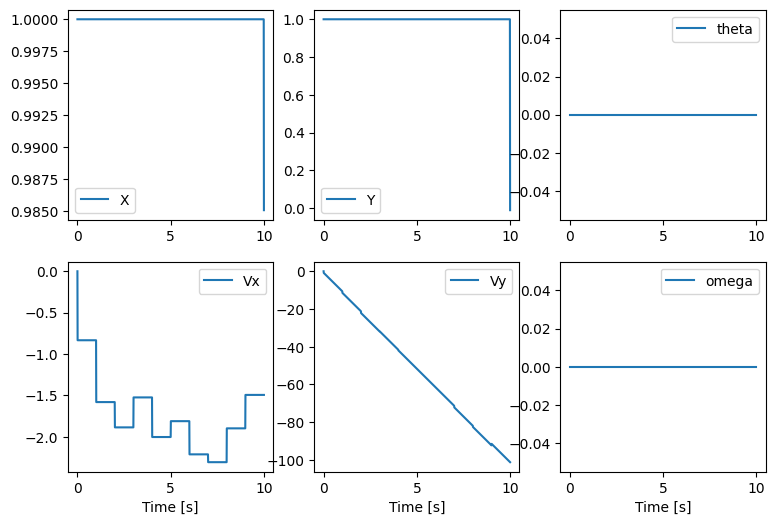

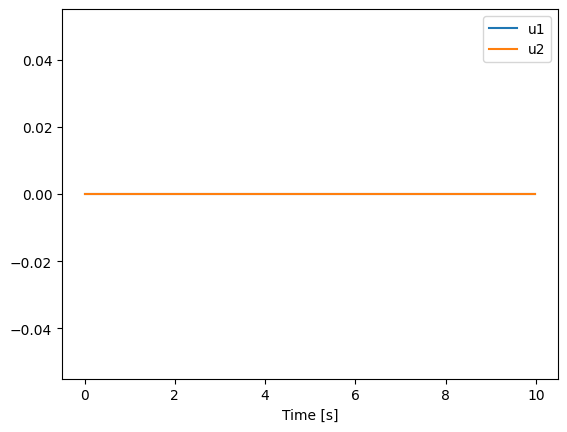

In [7]:
# we can also simulate with perturbations
t, state, u = quadrotor.simulate(z0, dummy_controller, horizon_length, disturbance = True)

# we can plot the results
plt.figure(figsize=[9,6])

plt.subplot(2,3,1)
plt.plot(t, state[0,:])
plt.legend(['X'])

plt.subplot(2,3,2)
plt.plot(t, state[2,:])
plt.legend(['Y'])

plt.subplot(2,3,3)
plt.plot(t, state[4,:])
plt.legend(["theta"])

plt.subplot(2,3,4)
plt.plot(t, state[1,:])
plt.legend(['Vx'])
plt.xlabel('Time [s]')

plt.subplot(2,3,5)
plt.plot(t, state[3,:])
plt.legend(['Vy'])
plt.xlabel('Time [s]')

plt.subplot(2,3,6)
plt.plot(t, state[5,:])
plt.legend(['omega'])
plt.xlabel('Time [s]')
save_plt(title="2D translation, orientaion and speed vs time b")

# we can also plot the control
plt.figure()
plt.plot(t[:-1], u.T)
plt.legend(['u1', 'u2'])
plt.xlabel('Time [s]')
save_plt(title="Control vs time b")

#quadrotor.animate_robot(state, u)
save_animate('my_animation b', quadrotor.animate_robot(state, u, pass_fps=True))